In [1]:
# cell 1: basics
import pandas as pd
import numpy as np

# scikit-learn for models
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# NLP basics
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Download any required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# cell 2: synthetic dataset generation
np.random.seed(42)

n_samples = 500

# unique teams
team_ids = [f"Team_{i:03d}" for i in range(1, n_samples+1)]

# Sales figures in GBP
sales = np.random.normal(loc=20000, scale=7000, size=n_samples).clip(min=0).round(2)

# Profit margins as percentage
profit_margin = np.random.normal(loc=15, scale=10, size=n_samples).clip(min=-50, max=70).round(2)

# Budget categories similar to quiz options
budget_categories = ["Up to £100", "Up to £250", "Up to £500", "£500+"]
budget = np.random.choice(budget_categories, size=n_samples, p=[0.15, 0.25, 0.35, 0.25])

# Demographics: region or age group categories as an example
regions = ["North West", "Greater Manchester", "London", "South East", "Other UK"]
age_groups = ["<18", "18-24", "25-34", "35-44", "45+"]
dem_region = np.random.choice(regions, size=n_samples, p=[0.3, 0.4, 0.1, 0.1, 0.1])
dem_age_group = np.random.choice(age_groups, size=n_samples, p=[0.05, 0.25, 0.35, 0.25, 0.1])

# Textual notes or comments for NLP examples
example_comments = [
    "Great performance during finals, fans loved it",
    "Poor start but recovered nicely",
    "High ticket sales, but costs were too high",
    "Strong local support from Manchester area",
    "New sponsorship boosted revenue",
    "Lost several matches due to injuries",
    "Excellent youth engagement program",
    "Marketing spend was lower than expected",
    "Merchandise overwhelmed warehouse stock",
    "Season ended with record profit"
]
comments = np.random.choice(example_comments, size=n_samples)

# Construct dataframe
df = pd.DataFrame({
    "team_id": team_ids,
    "sales_gbp": sales,
    "profit_margin_pct": profit_margin,
    "budget_category": budget,
    "region": dem_region,
    "age_group": dem_age_group,
    "notes": comments
})

# Preview
df.head()

,team_id,sales_gbp,profit_margin_pct,budget_category,region,age_group,notes
0,Team_001,23477.00,24.26,Up to £250,London,18-24,Excellent youth engagement program
1,Team_002,19032.15,34.09,Up to £100,North West,<18,Lost several matches due to injuries
2,Team_003,24533.82,1.01,Up to £500,North West,18-24,Lost several matches due to injuries
3,Team_004,30661.21,20.63,Up to £500,North West,25-34,Poor start but recovered nicely
4,Team_005,18360.93,8.49,Up to £100,Other UK,35-44,Season ended with record profit


In [3]:
# cell 3: save to CSV
df.to_csv("fantasy_football_sales_demographics.csv", index=False)

In [4]:
# cell 4: load from CSV
data = pd.read_csv("fantasy_football_sales_demographics.csv")
data.info()
data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   team_id            500 non-null    object 
 1   sales_gbp          500 non-null    float64
 2   profit_margin_pct  500 non-null    float64
 3   budget_category    500 non-null    object 
 4   region             500 non-null    object 
 5   age_group          500 non-null    object 
 6   notes              500 non-null    object 
dtypes: float64(2), object(5)
memory usage: 27.5+ KB


,team_id,sales_gbp,profit_margin_pct,budget_category,region,age_group,notes
count,500,500.000000,500.000000,500,500,500,500
unique,500,NaN,NaN,4,5,5,10
top,Team_001,NaN,NaN,Up to £500,Greater Manchester,25-34,Strong local support from Manchester area
freq,1,NaN,NaN,187,192,182,57
mean,NaN,20053.243580,15.318040,NaN,NaN,NaN,NaN
std,NaN,6851.967991,9.780113,NaN,NaN,NaN,NaN
min,NaN,0.000000,-11.970000,NaN,NaN,NaN,NaN
25%,NaN,15097.847500,9.050000,NaN,NaN,NaN,NaN
50%,NaN,20089.580000,15.285000,NaN,NaN,NaN,NaN
75%,NaN,24457.480000,21.510000,NaN,NaN,NaN,NaN


In [5]:
# cell 5
missing_summary = data.isnull().sum()
print(missing_summary)

team_id              0
sales_gbp            0
profit_margin_pct    0
budget_category      0
region               0
age_group            0
notes                0
dtype: int64


In [6]:
# cell 6: target
# Define high profit as profit_margin_pct >= 20%
data["high_profit"] = (data["profit_margin_pct"] >= 20).astype(int)

data["high_profit"].value_counts()

high_profit
0    346
1    154
Name: count, dtype: int64

In [7]:
# cell 7
# Select features: budget_category, region, age_group; plus sales maybe
features = ["sales_gbp", "budget_category", "region", "age_group"]

# Encode categorical with LabelEncoder or one-hot for Decision Tree
le_budget = LabelEncoder()
le_region = LabelEncoder()
le_age = LabelEncoder()

data["budget_enc"] = le_budget.fit_transform(data["budget_category"])
data["region_enc"] = le_region.fit_transform(data["region"])
data["age_enc"] = le_age.fit_transform(data["age_group"])

feature_cols = ["sales_gbp", "budget_enc", "region_enc", "age_enc"]

X = data[feature_cols]
y = data["high_profit"]

X.head()

,sales_gbp,budget_enc,region_enc,age_enc
0,23477.00,1,1,0
1,19032.15,0,2,4
2,24533.82,2,2,0
3,30661.21,2,2,1
4,18360.93,0,3,2


In [13]:
print(X.columns.tolist())

['sales_scaled', 'budget_enc', 'region_enc', 'age_enc']


In [14]:
# cell 9
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [15]:
# cell 10
clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4, # adjust depth for simplicity/overfitting
    random_state=42
)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.90      0.77        87
           1       0.10      0.03      0.04        38

    accuracy                           0.63       125
   macro avg       0.39      0.46      0.41       125
weighted avg       0.50      0.63      0.55       125

Confusion Matrix:
[[78  9]
 [37  1]]


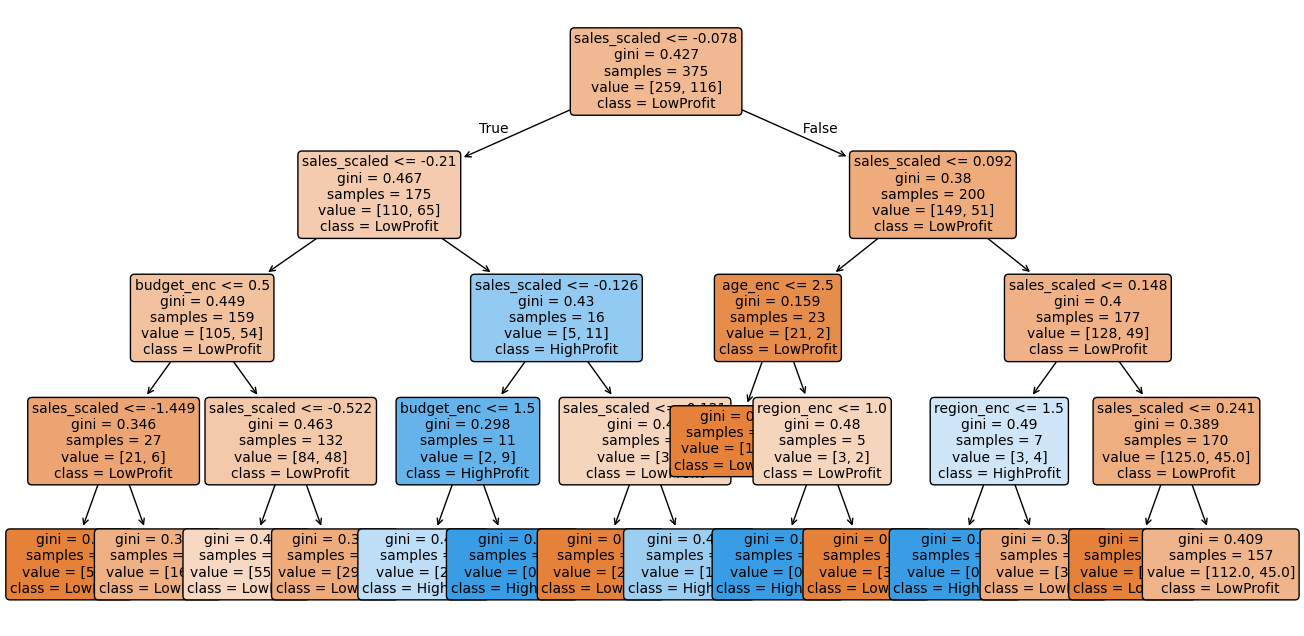

In [16]:
# cell 11
plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=feature_cols_scaled,
    class_names=["LowProfit", "HighProfit"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [17]:
# cell 12: prepare text
# Lowercase, basic tokenization, stopwords removal can be part of vectorizer steps
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords.words("english"),
    ngram_range=(1, 2), # unigrams + bigrams
    max_features=200
)

# Fit on all comments
tfidf_matrix = vectorizer.fit_transform(data["notes"])

In [19]:
# Separate indices (convert pandas Series -> NumPy array)
idx_high = (data["high_profit"] == 1).to_numpy()
idx_low = (data["high_profit"] == 0).to_numpy()

# Compute mean TF-IDF per feature
mean_high = tfidf_matrix[idx_high].mean(axis=0)
mean_low = tfidf_matrix[idx_low].mean(axis=0)

# Convert sparse matrices to arrays
mean_high = np.asarray(mean_high).flatten()
mean_low = np.asarray(mean_low).flatten()

# Get feature names
terms = vectorizer.get_feature_names_out()

# Compute difference between classes
diff = mean_high - mean_low

# Number of terms to show
top_n = 10

# Indices of largest positive and negative differences
idx_top_high = np.argsort(diff)[-top_n:][::-1]
idx_top_low = np.argsort(diff)[:top_n]

print("Top terms more common in high-profit notes:")
for i in idx_top_high:
    print(f"{terms[i]}: diff {diff[i]:.4f}")

print("\nTop terms more common in low-profit notes:")
for i in idx_top_low:
    print(f"{terms[i]}: diff {diff[i]:.4f}")

Top terms more common in high-profit notes:
new: diff 0.0338
sponsorship: diff 0.0338
revenue: diff 0.0338
new sponsorship: diff 0.0338
sponsorship boosted: diff 0.0338
boosted: diff 0.0338
boosted revenue: diff 0.0338
spend: diff 0.0229
marketing: diff 0.0229
expected: diff 0.0229

Top terms more common in low-profit notes:
matches due: diff -0.0167
matches: diff -0.0167
several: diff -0.0167
several matches: diff -0.0167
due: diff -0.0167
due injuries: diff -0.0167
lost several: diff -0.0167
lost: diff -0.0167
injuries: diff -0.0167
area: diff -0.0111


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_78843/1035759677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals, y=top_labels, palette="coolwarm")


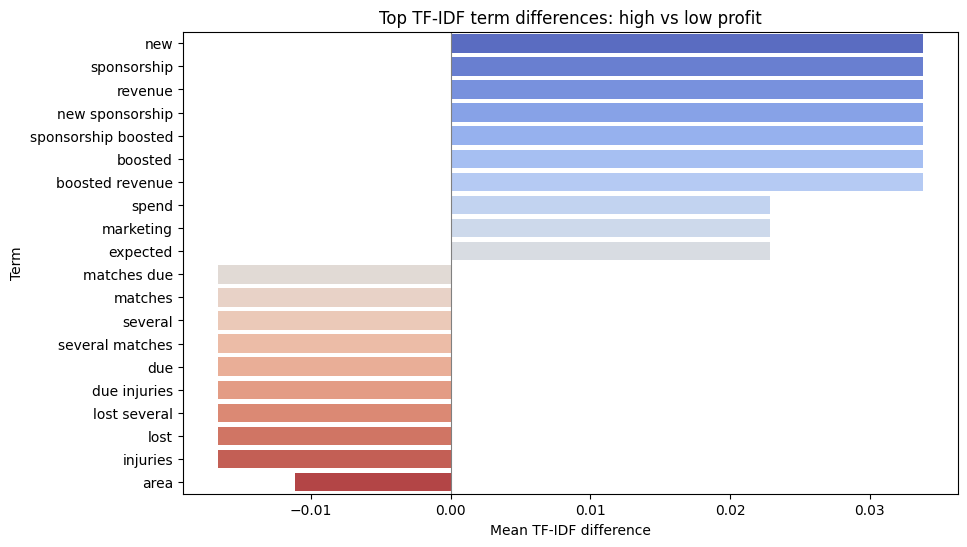

In [20]:
# cell 14
# Combine top terms into bar chart
top_terms = np.concatenate([idx_top_high, idx_top_low])
top_labels = [terms[i] for i in top_terms]
top_vals = [diff[i] for i in top_terms]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_vals, y=top_labels, palette="coolwarm")
plt.title("Top TF-IDF term differences: high vs low profit")
plt.xlabel("Mean TF-IDF difference")
plt.ylabel("Term")
plt.axvline(0, color='grey', linewidth=0.8)
plt.show()

In [23]:
dir()

['DecisionTreeClassifier',
 'In',
 'LabelEncoder',
 'Out',
 'StandardScaler',
 'TfidfVectorizer',
 'X',
 'X_scaled',
 'X_test',
 'X_train',
 '_',
 '_1',
 '_2',
 '_4',
 '_6',
 '_7',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'age_groups',
 'budget',
 'budget_categories',
 'classification_report',
 'clf',
 'comments',
 'confusion_matrix',
 'data',
 'dem_age_group',
 'dem_region',
 'df',
 'diff',
 'example_comments',
 'exit',
 'feature_cols',
 'feature_cols_scaled',
 'features',
 'get_ipython',
 'i',
 'idx_high',
 'idx_low',
 'idx_top_high',
 'idx_top_low',
 'le_age',
 'le_budget',
 'le_region',
 'mean_high',
 'mean_low',
 'missing_summary',
 'n_samples',
 '

In [25]:
# cell 15: load Manchester data
manchester_df = pd.read_csv("path_to_manchester.csv")
manchester_df.head()

,step,location,latitude,longitude
0,1,Birmingham,52.4862,-1.8904
1,2,Stoke-on-Trent,53.0027,-2.1794
2,3,Macclesfield,53.2587,-2.1250
3,4,Stockport,53.4084,-2.1495
4,5,Manchester,53.4808,-2.2426


In [27]:
print(manchester_df.columns)

Index(['step', 'location', 'latitude', 'longitude'], dtype='object')


In [32]:
print(df.columns)
print(manchester_df.columns)

Index(['team_id', 'sales_gbp', 'profit_margin_pct', 'budget_category',
       'region', 'age_group', 'notes'],
      dtype='object')
Index(['step', 'location', 'latitude', 'longitude'], dtype='object')


In [33]:
# cell 18: save model with joblib
import joblib

joblib.dump(clf, "decision_tree_fantasy_profit.pkl")
joblib.dump(scaler, "sales_scaler.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']